In [85]:
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt 

In [86]:
df = pd.read_csv("../Medical_insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [87]:
col=df.columns
col

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

<h3>claining<h3>

In [88]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Axes: >

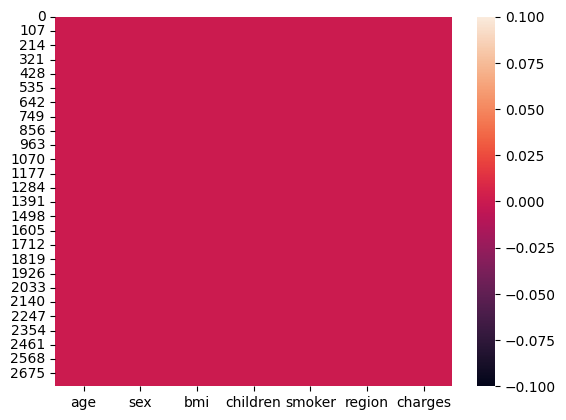

In [89]:
sns.heatmap(df.isna())

<h3>labiling coding<h3>

In [90]:
df["sex"]=df["sex"].astype("category").cat.codes

In [91]:
df["smoker"]=df["smoker"].astype("category").cat.codes

In [92]:
df["region"]=df["region"].astype("category").cat.codes

In [93]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
2767,47,0,45.320,1,0,2,8569.86180
2768,21,0,34.600,0,0,3,2020.17700
2769,19,1,26.030,1,1,1,16450.89470
2770,23,1,18.715,0,0,1,21595.38229


<h3>data scaling <h3>

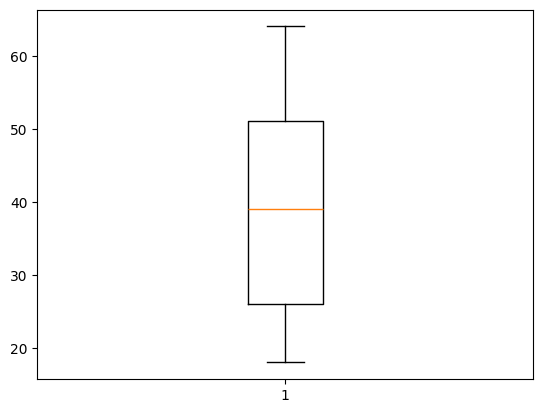

In [94]:
plt.boxplot(df["age"])
plt.show()

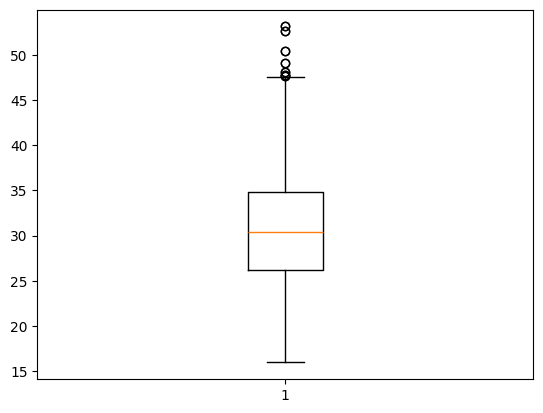

In [95]:
plt.boxplot(df["bmi"])
plt.show()

In [96]:
q1=df["bmi"].quantile(0.25)
q1

np.float64(26.22)

In [97]:
q3=df["bmi"].quantile(0.75)
q3

np.float64(34.77)

In [98]:
IQR=q3-q1
IQR

np.float64(8.550000000000004)

In [99]:
df = df[(df['bmi'] >= q1 - 1.5*IQR) & (df['bmi'] <= q3 + 1.5*IQR)]

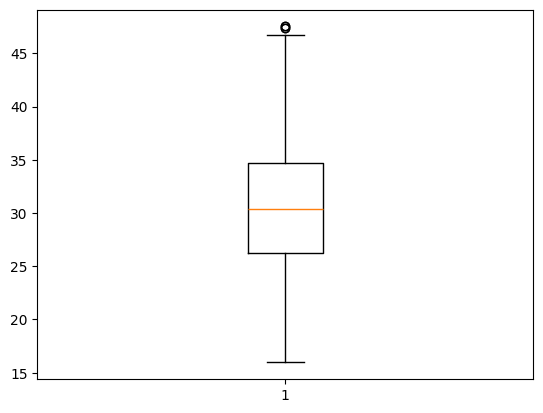

In [100]:
plt.boxplot(df["bmi"])
plt.show()

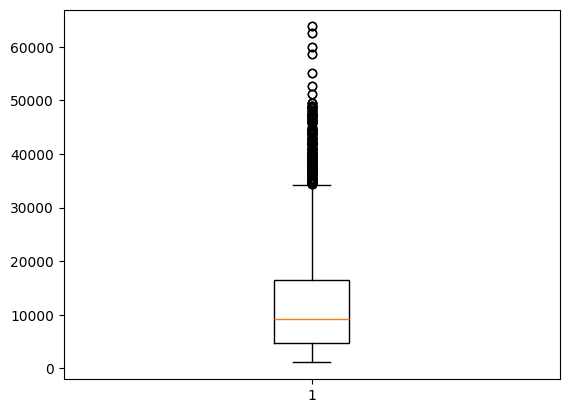

In [101]:
plt.boxplot(df["charges"])
plt.show()

In [102]:
nu=df["charges"].mean()
s=df["charges"].std()
df["charges"]=(df["charges"]-nu)/s


C:\Users\hp\AppData\Local\Temp\ipykernel_18960\3441610661.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["charges"]=(df["charges"]-nu)/s


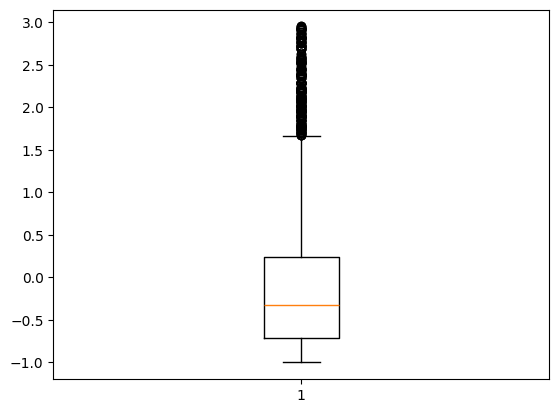

In [103]:
df = df[abs(df["charges"]) <= 3]
plt.boxplot(df["charges"])
plt.show()

<h3>classification with decision tree<h3>

In [104]:
x = df[['age','sex','bmi','children','smoker','region']]
y = df['charges']

In [105]:
from sklearn.model_selection import train_test_split

x_train ,x_test, y_train ,y_test = train_test_split(x,y,test_size=0.2)

In [106]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor()

tree_model.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [107]:
y_pred = tree_model.predict(x_test)
y_pred

array([ 6.22773238e-01, -6.45055311e-01,  5.04620085e-01,  7.13533922e-01,
       -9.35305630e-02, -8.28650259e-01, -8.22382652e-01, -1.69292770e-01,
        1.14591456e+00,  8.02758947e-02, -7.33853569e-01, -1.30451767e-01,
       -2.55448559e-02, -5.74283987e-01, -3.05183189e-01, -6.94353358e-01,
       -8.22382652e-01, -3.12969675e-01, -3.69286553e-01, -6.29340390e-01,
       -8.39419081e-01, -2.45099015e-01, -8.05278714e-01, -7.22113629e-02,
       -6.45828250e-01,  2.75942009e+00, -4.04852660e-01, -3.09645664e-01,
       -3.75593318e-01, -8.98683914e-01,  2.72587353e+00,  2.81140086e+00,
        6.69602634e-01, -1.12206933e-01, -7.99510087e-01,  9.27831278e-01,
       -9.35305630e-02, -6.90219079e-01, -9.11222400e-01, -8.38900044e-01,
        2.10303221e+00,  8.39144960e-02, -7.38244997e-01, -6.92783465e-01,
       -8.40609645e-01, -3.64346415e-01, -3.81666330e-01,  8.52849822e-01,
       -1.74255067e-03,  5.16702752e-01,  1.76510131e+00,  2.86141040e+00,
       -8.57592579e-01, -

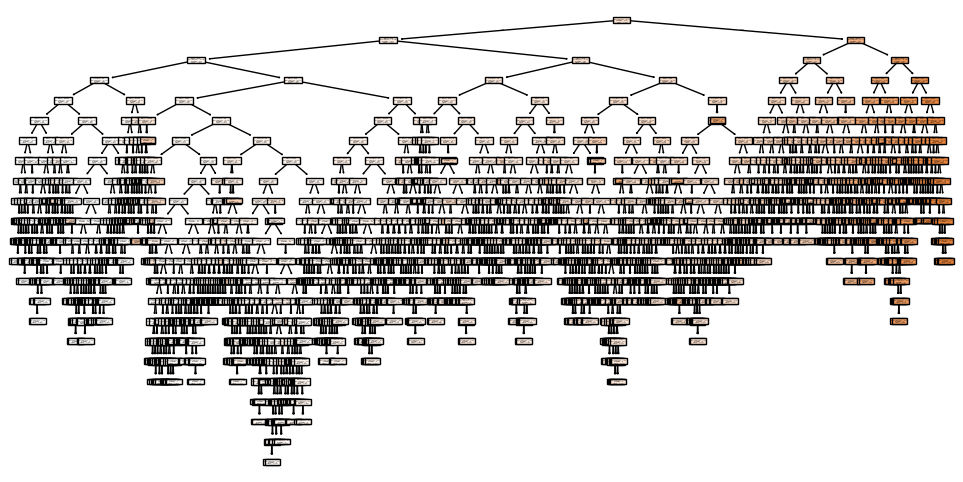

In [108]:
#visualisation de l'arbre 
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plot_tree(tree_model, feature_names=x.columns, filled=True)
plt.show()

<h3>classification avec svm<h3>

In [109]:
from sklearn.svm import SVR
model=SVR(kernel="linear")
model.fit(x_train,y_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [110]:
model.predict(x_test)

array([-0.17464852, -0.59088601,  1.74042762,  2.0699787 , -0.0864387 ,
       -0.78212411, -0.65975955, -0.15032214, -0.30481693,  0.06334715,
       -0.65699702, -0.14923086, -0.0398733 , -0.50905069, -0.13725413,
       -0.7642488 , -0.65975955, -0.29460351, -0.25298795, -0.67538811,
       -0.81616767, -0.19358811, -0.83761279, -0.04726042, -0.58241448,
        2.42876136, -0.30553795, -0.26488863, -0.37439197, -0.9198597 ,
        2.40603203,  2.54135489,  1.9890417 , -0.09955554, -0.77103997,
       -0.22014458, -0.11459182, -0.71981822, -1.00362679, -0.90742272,
        1.85448565, -0.03818437, -0.84764131, -0.64496611, -0.85552389,
       -0.32962942, -0.31516595,  2.10915422, -0.07244733, -0.3730338 ,
        1.53087102,  2.4993076 , -0.84335885, -0.84764131, -0.60012111,
       -0.74882267, -0.4949148 , -0.9571436 , -0.17375588,  0.03112537,
       -0.61351642, -0.71461172, -0.98290338, -0.95910073, -0.93753778,
       -0.9491605 ,  1.77329663, -0.11366332,  1.73921669, -0.28

ValueError: x and y must be the same size

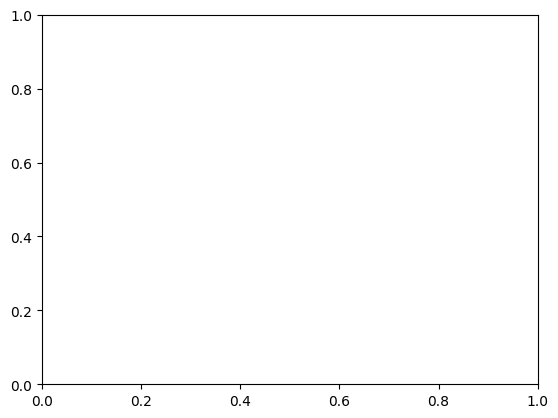

In [111]:
#visualiser les points 
import matplotlib.pyplot as plt

plt.scatter(y, X['bmi'], c=y)
plt.xlabel("charges")
plt.ylabel("bmi")
plt.show()

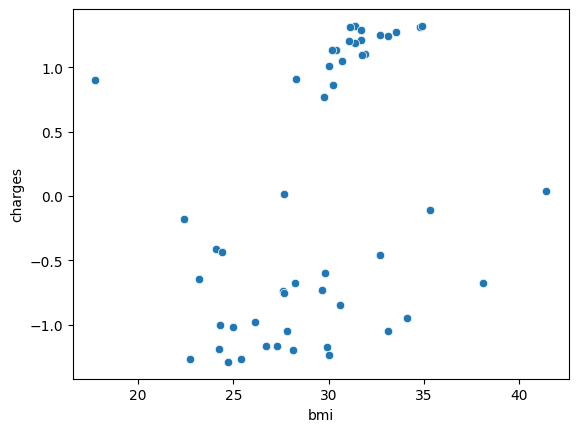

In [ ]:
import seaborn as sns

sns.scatterplot(x='bmi', y='charges', data=df)
plt.show()

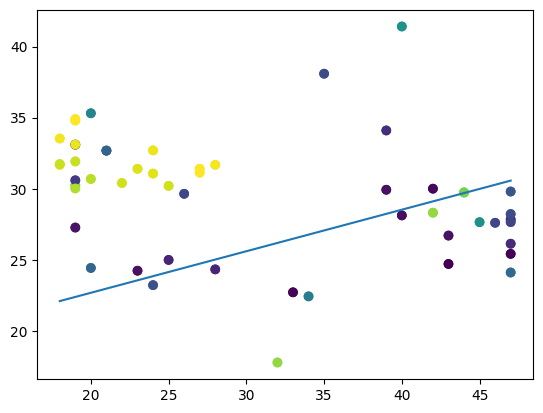

In [ ]:
import numpy as np

w = model.coef_[0]
b = model.intercept_

x_points = np.linspace(x['age'].min(), x['age'].max())
y_points = -(w[0]*x_points + b) / w[1]

plt.scatter(x['age'], x['bmi'], c=y)
plt.plot(x_points, y_points)
plt.show()

<h3>regression<h3>

In [ ]:
from sklearn.linear_model import LinearRegression

reg_model= LinearRegression()
reg_model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pr=reg_model.predict(x)
y_pr

array([-0.72126382,  0.82244876, -0.56552952, -0.92121467, -0.64129715,
        1.11547787,  1.01451999, -0.12781363, -0.35317001,  0.4694469 ,
       -0.65468453, -0.92153536,  0.23886516,  0.12064888, -0.73962033,
        0.89327613,  0.26743743, -0.22763466,  0.84673962,  1.16445698,
       -0.2918839 , -0.18687669, -1.44173616,  0.59726792, -0.33324333,
       -0.20521393, -0.4600804 ,  1.0647915 , -0.83460745, -1.12446904,
        0.84087344, -0.35077237, -0.49401455, -0.17569257, -0.20677374,
        0.94363038, -0.53163453, -0.32131965,  0.68666526,  0.63094586,
        0.596367  , -0.47926703,  0.70515373, -0.49300319,  0.33517966,
        0.83769248,  0.2080371 , -0.49594253,  1.1209995 ,  0.46664735,
       -0.67697414, -0.83460745, -0.17569257, -0.72126382,  0.82244876,
       -0.56552952, -0.92121467, -0.64129715,  1.11547787,  1.01451999,
       -0.12781363, -0.35317001,  0.4694469 , -0.65468453, -0.92153536,
        0.23886516,  0.12064888, -0.73962033,  0.89327613,  0.26

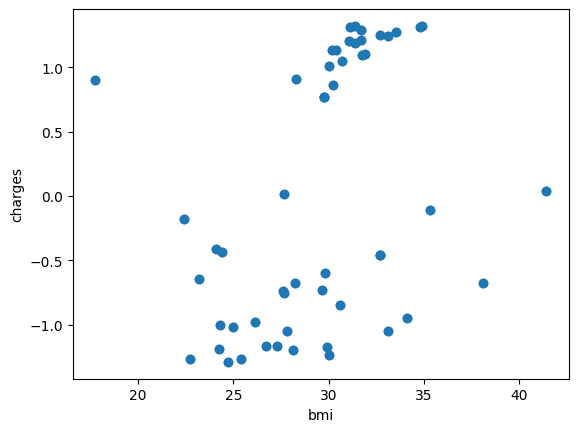

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['bmi'], df['charges'])
plt.xlabel("bmi")
plt.ylabel("charges")
plt.show()

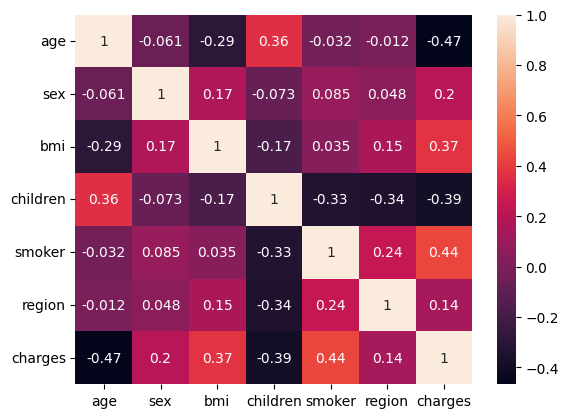

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

sns.heatmap(corr, annot=True)
plt.show()

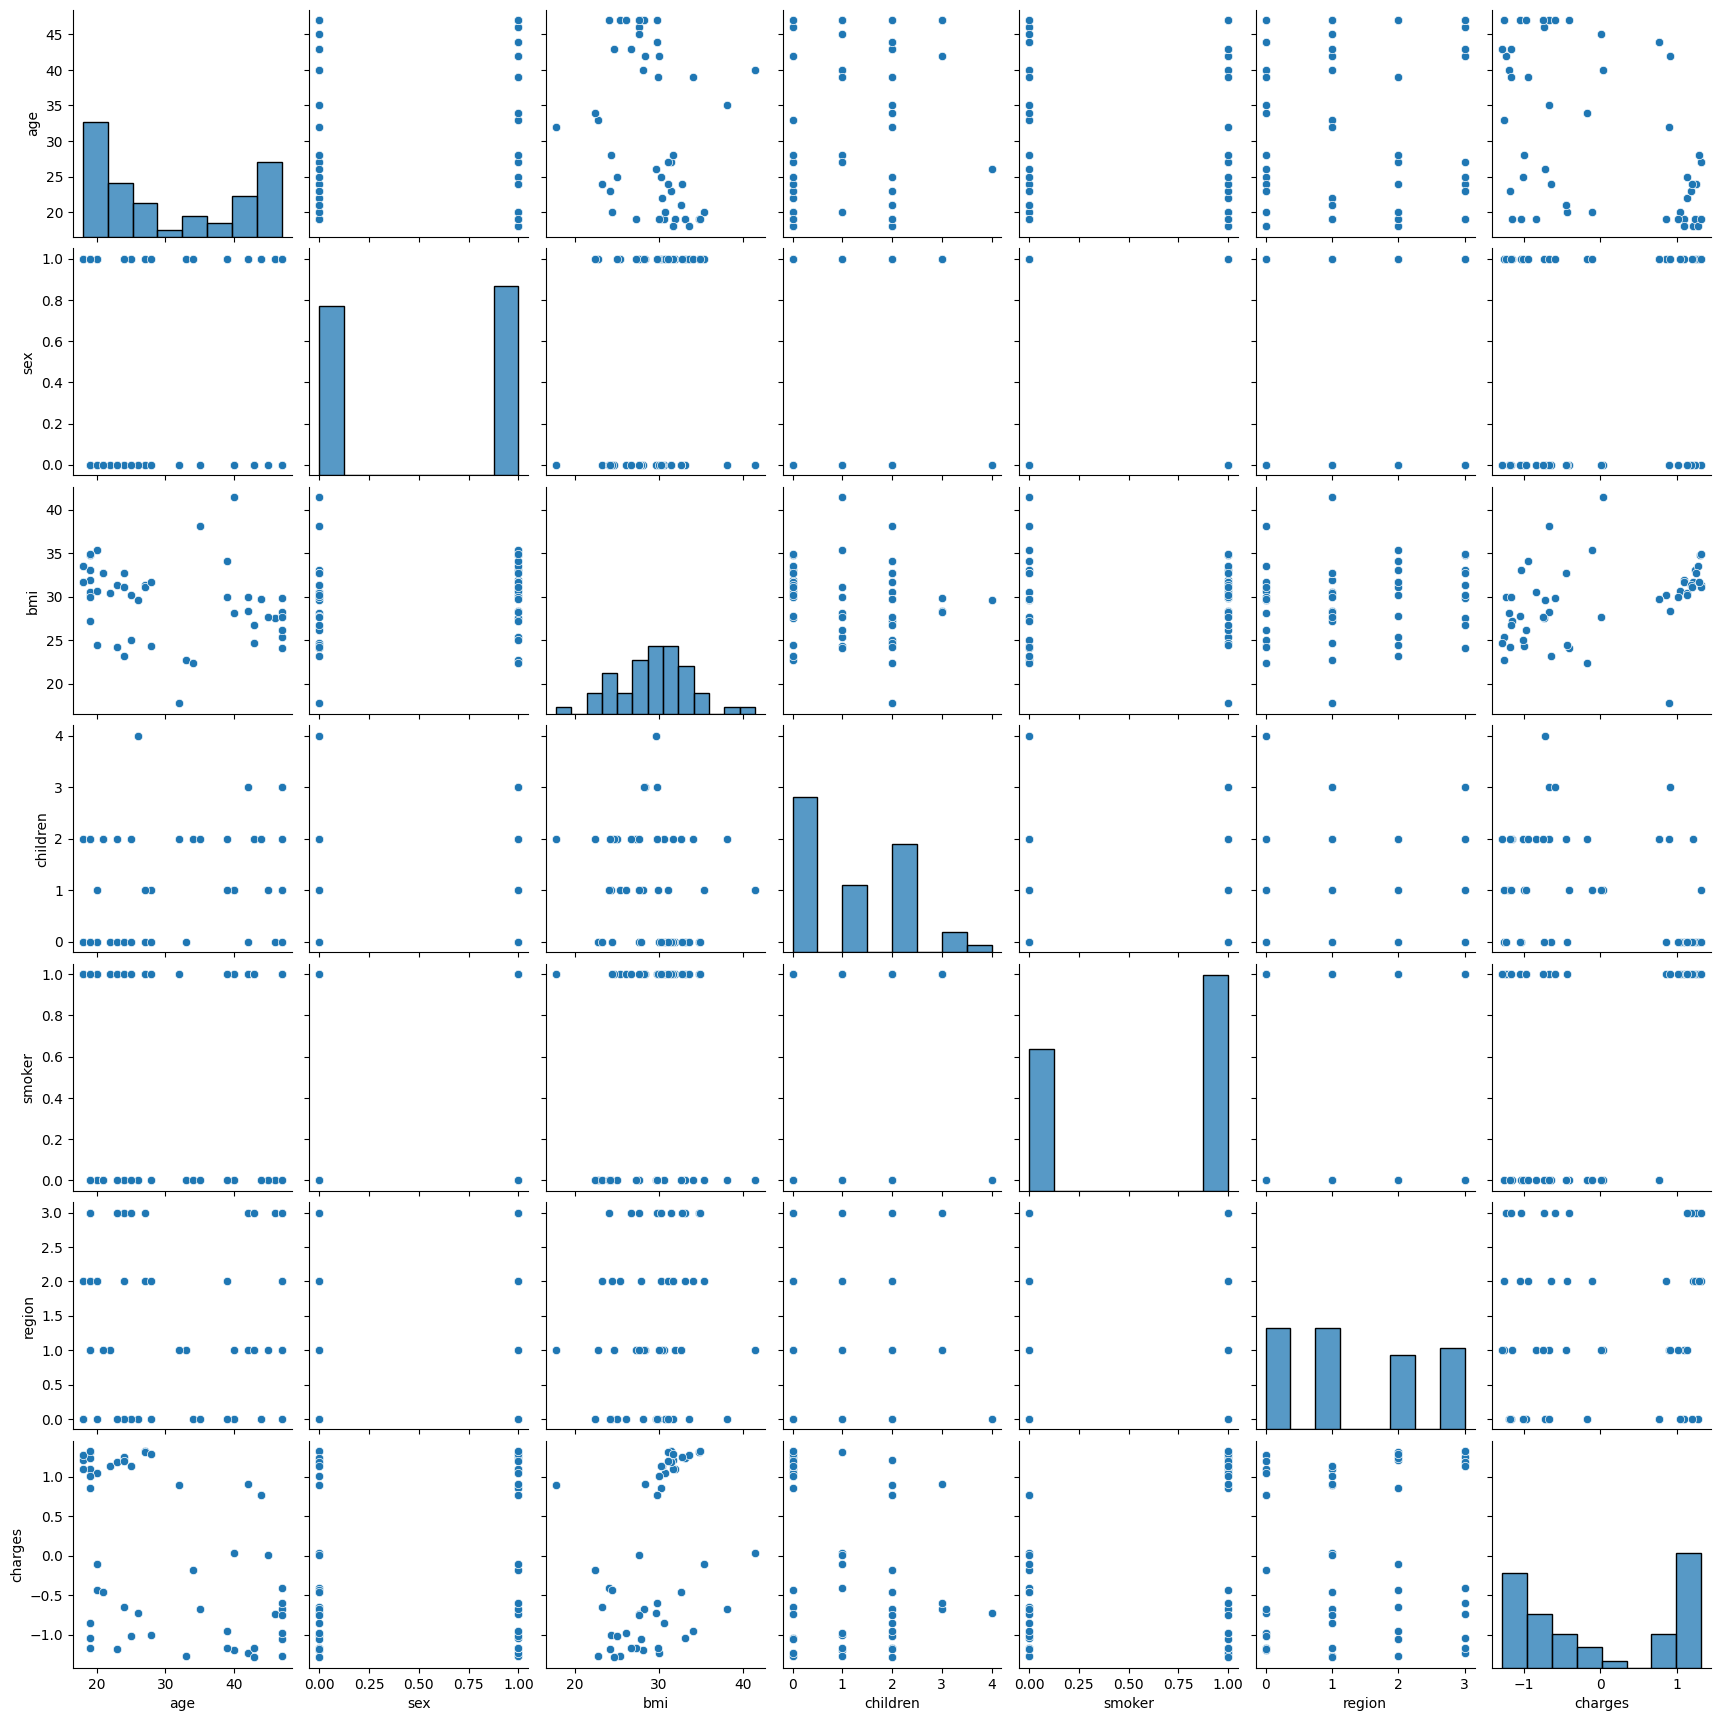

In [ ]:
sns.pairplot(df)
plt.show()

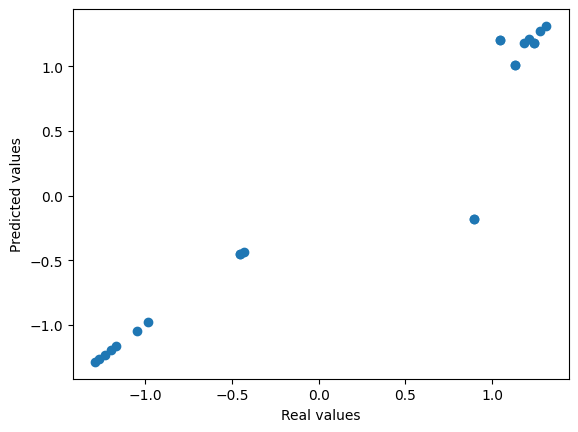

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Real values")
plt.ylabel("Predicted values")
plt.show()

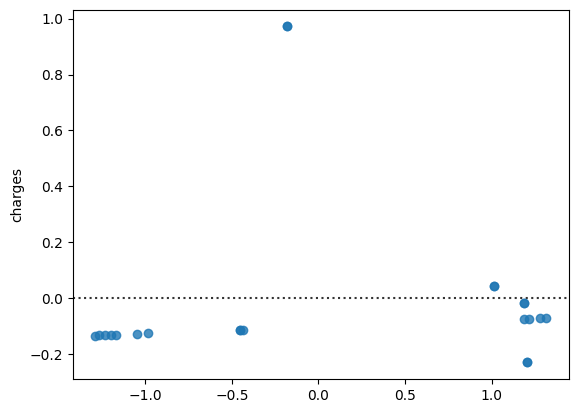

In [ ]:
import seaborn as sns

sns.residplot(x=y_pred, y=y_test)
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df)
plt.show()

In [ ]:
sns.pairplot(df, hue="smoker")
plt.show()

In [ ]:
sns.pairplot(df)
plt.show()

In [ ]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

In [ ]:
sns.violinplot(x='smoker', y='charges', data=df)
plt.show()